# How max_depth Impacts Variance in Decision Trees (and Gradient Boosting)

### 🎯 How `max_depth` Impacts Variance in Decision Trees (and Gradient Boosting)

The `max_depth` parameter controls **how deep** a decision tree can grow. It affects how complex the model is—and therefore directly impacts **variance** and **bias**.

---

### 📈 Deeper Trees → **Higher Variance**, Lower Bias

* When `max_depth` is **large**:

  * Trees can **fit the training data very closely**, capturing fine-grained patterns (and noise).
  * ➤ **Low bias**: The model learns the data well.
  * ➤ **High variance**: It may not generalize well to unseen data (i.e., overfitting).

---

### 📉 Shallower Trees → **Lower Variance**, Higher Bias

* When `max_depth` is **small** (e.g., 1 to 3):

  * Trees are **simple**, capturing only general trends.
  * ➤ **High bias**: Model may underfit the data.
  * ➤ **Low variance**: Predictions are more stable and generalize better.

---

### 🔁 In Gradient Boosting

In **Gradient Boosting**, we typically use **shallow trees** (also called **weak learners**, e.g., `max_depth=3`) because:

* Shallow trees keep each individual learner simple and **low-variance**.
* Boosting builds strength **incrementally**, reducing bias step-by-step.
* Using deep trees would increase the **risk of overfitting**, especially when combined with a high `n_estimators`.

---

### 🔍 Summary Table

| `max_depth` | Model Complexity | Bias | Variance | Risk                    |
| ----------- | ---------------- | ---- | -------- | ----------------------- |
| Low (1–3)   | Simple           | High | Low      | Underfitting possible   |
| High (5+)   | Complex          | Low  | High     | Overfitting more likely |

---

**Tip:**
In boosting, prefer shallow trees with `max_depth=3–5` to maintain low variance and let the ensemble reduce bias gradually.

## code experiment

Here's a beginner-friendly **code experiment** to observe how `max_depth` impacts **bias vs. variance** in Gradient Boosting using `GradientBoostingRegressor`.

---

### ✅ Goal:

Test different `max_depth` values and evaluate their impact on performance using training and test RMSE (Root Mean Squared Error).

---



📦 Setup

In [1]:
# Import required libraries
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Generate synthetic regression data
X, y = make_regression(n_samples=1000, n_features=20, noise=0.1, random_state=42)

# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

🔁 Experiment with max_depth

In [3]:
# Try different max_depth values
depths = [1, 2, 3, 4, 5, 6, 10]
train_rmse = []
test_rmse = []

for depth in depths:
    # Initialize model
    gbr = GradientBoostingRegressor(max_depth=depth, n_estimators=300, learning_rate=0.1, random_state=42)

    # Train model
    gbr.fit(X_train, y_train)

    # Predict and calculate RMSE
    y_train_pred = gbr.predict(X_train)
    y_test_pred = gbr.predict(X_test)

    rmse_train = mean_squared_error(y_train, y_train_pred) ** 0.5
    rmse_test = mean_squared_error(y_test, y_test_pred) ** 0.5

    train_rmse.append(rmse_train)
    test_rmse.append(rmse_test)

    print(f"Depth: {depth} | Train RMSE: {rmse_train:.2f} | Test RMSE: {rmse_test:.2f}")

Depth: 1 | Train RMSE: 30.47 | Test RMSE: 44.57
Depth: 2 | Train RMSE: 14.85 | Test RMSE: 39.87
Depth: 3 | Train RMSE: 9.85 | Test RMSE: 46.25
Depth: 4 | Train RMSE: 4.47 | Test RMSE: 53.62
Depth: 5 | Train RMSE: 1.52 | Test RMSE: 62.19
Depth: 6 | Train RMSE: 0.48 | Test RMSE: 68.51
Depth: 10 | Train RMSE: 0.00 | Test RMSE: 106.27


📊 Visualize Bias vs. Variance

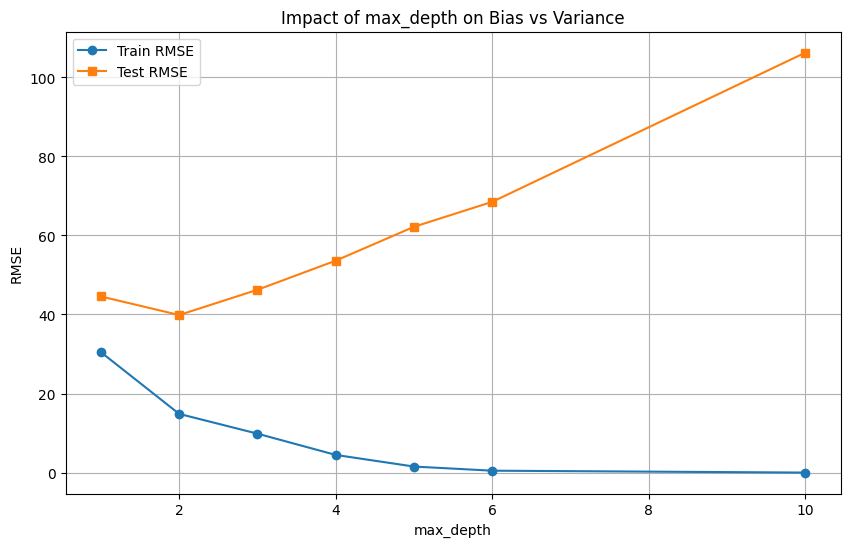

In [4]:
# Plot RMSE for each depth
plt.figure(figsize=(10, 6))
plt.plot(depths, train_rmse, marker='o', label='Train RMSE')
plt.plot(depths, test_rmse, marker='s', label='Test RMSE')
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.title('Impact of max_depth on Bias vs Variance')
plt.legend()
plt.grid(True)
plt.show()

### 🔍 What You'll See:

* **Shallow trees (low `max_depth`)** will have high train RMSE (underfitting).
* **Deeper trees (high `max_depth`)** will reduce train RMSE, but **test RMSE may rise** after a point (overfitting).
* The **best depth** balances low train error and generalization to test data.